In [ ]:
# ============================================================
# CELL 1 — DATASET DOWNLOAD
# ============================================================

import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download(
    "ajg117/indian-paintings-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 355M/355M [00:02<00:00, 162MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3


In [ ]:
# ============================================================
# CELL 2 — LIBRARY IMPORTS
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split, Dataset

import torchvision
from torchvision import datasets, transforms, models

from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ============================================================
# CELL 3 — DEVICE CONFIGURATION
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [ ]:
# ============================================================
# CELL 4 — DATASET PATH CONFIGURATION & INSPECTION
# ============================================================

dataset_path = path

print("Dataset path:", dataset_path)

print("\nContents of dataset directory:")

for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)

    if os.path.isdir(full_path):
        print("[DIR] ", item)
    else:
        print("[FILE]", item)

Dataset path: /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3

Contents of dataset directory:
[DIR]  gond painting
[FILE] classes.csv
[DIR]  mandana art drawing
[DIR]  kalighat painting
[DIR]  kangra painting
[FILE] LICENSE
[DIR]  madhubani painting
[DIR]  warli painting
[DIR]  kerala mural
[DIR]  pichwai painting


In [ ]:
# ============================================================
# CELL 5 — DATASET LOADING & CLASS INSPECTION
# ============================================================

base_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=None
)

print("Total images:", len(base_dataset))
print("Number of classes:", len(base_dataset.classes))

print("\nClasses:")
for idx, class_name in enumerate(base_dataset.classes):
    print(idx, ":", class_name)

print("\nClass to index:")
print(base_dataset.class_to_idx)

Total images: 953
Number of classes: 8

Classes:
0 : gond painting
1 : kalighat painting
2 : kangra painting
3 : kerala mural
4 : madhubani painting
5 : mandana art drawing
6 : pichwai painting
7 : warli painting

Class to index:
{'gond painting': 0, 'kalighat painting': 1, 'kangra painting': 2, 'kerala mural': 3, 'madhubani painting': 4, 'mandana art drawing': 5, 'pichwai painting': 6, 'warli painting': 7}


In [ ]:
# ============================================================
# CELL 6 — NUMBER OF CLASSES
# ============================================================

NUM_CLASSES = len(base_dataset.classes)

print("Number of classes:", NUM_CLASSES)

assert NUM_CLASSES == 8, (
    f"Expected 8 classes based on the reference experiment, "
    f"but found {NUM_CLASSES}."
)

Number of classes: 8


In [ ]:
# ============================================================
# CELL 7 — IMAGE TRANSFORMATIONS
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully.")

Transforms created successfully.


In [ ]:
# ============================================================
# CELL 8 — TRAIN / VALIDATION / TEST SPLIT
# ============================================================

total_size = len(base_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset, test_subset = random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Total images:", total_size)
print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Testing images:", len(test_subset))

Total images: 953
Training images: 667
Validation images: 142
Testing images: 144


In [ ]:
# ============================================================
# CELL 9 — TRANSFORM ASSIGNMENT TO DATASET SUBSETS
# ============================================================

class TransformSubset(Dataset):

    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):

        image, label = self.subset[index]

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = TransformSubset(
    train_subset,
    train_transform
)

val_dataset = TransformSubset(
    val_subset,
    test_transform
)

test_dataset = TransformSubset(
    test_subset,
    test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 667
Validation dataset: 142
Test dataset: 144


In [ ]:
# ============================================================
# CELL 10 — DATALOADERS
# ============================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created.")
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created.
Train batches: 21
Validation batches: 5
Test batches: 5


In [ ]:
# ============================================================
# CELL 11 — BATCH VERIFICATION
# ============================================================

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: tensor([5, 2, 1, 5, 4, 5, 4, 4, 0, 7])


In [ ]:
# ============================================================
# CELL 12 — LOAD PRETRAINED EFFICIENTNET-B0
# ============================================================

weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)

print("Pretrained EfficientNet-B0 loaded successfully.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 77.6MB/s]


Pretrained EfficientNet-B0 loaded successfully.


In [ ]:
# ============================================================
# CELL 13 — EFFICIENTNET-B0 FEATURE EXTRACTOR
# ============================================================

# Get the feature dimension before removing the classifier
num_features = model.classifier[1].in_features

print("EfficientNet-B0 feature size:", num_features)

# Remove the original ImageNet classification head
model.classifier = nn.Identity()

# Move model to the selected device
model = model.to(device)

# Set model to evaluation mode
model.eval()

print("EfficientNet-B0 feature extractor ready.")
print("Output feature dimension:", num_features)

EfficientNet-B0 feature size: 1280
EfficientNet-B0 feature extractor ready.
Output feature dimension: 1280


In [ ]:
# ============================================================
# CELL 14 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [ ]:
# ============================================================
# CELL 14 — LOAD BEST TRAINED EFFICIENTNET-B0
# ============================================================

# Recreate EfficientNet-B0 with the same architecture
# used during the original training

weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)

# Configure the same 8-class classifier used during training
num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, NUM_CLASSES)
)

# Move model to device
model = model.to(device)

# Path of the saved best model
best_model_path = (
    "/content/drive/MyDrive/Iconography/Implementation/"
    "EfficientNet-B0/best_efficientnet_b0_indian_paintings.pth"
)

# Load best trained checkpoint
model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model.eval()

print("Best trained EfficientNet-B0 loaded successfully.")
print("Checkpoint:", best_model_path)
print("Feature dimension:", num_features)

Best trained EfficientNet-B0 loaded successfully.
Checkpoint: /content/drive/MyDrive/Iconography/Implementation/EfficientNet-B0/best_efficientnet_b0_indian_paintings.pth
Feature dimension: 1280


In [ ]:
# ============================================================
# CELL 15 — CONVERT TO FEATURE EXTRACTOR
# ============================================================

# Remove the trained classification head
model.classifier = nn.Identity()

# Keep the model on the selected device
model = model.to(device)

# Evaluation mode for feature extraction
model.eval()

print("EfficientNet-B0 is now a feature extractor.")
print("Feature dimension:", num_features)

EfficientNet-B0 is now a feature extractor.
Feature dimension: 1280


In [ ]:
# ============================================================
# CELL 16 — FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_features(model, loader, device):

    model.eval()

    features = []
    labels = []

    with torch.no_grad():

        for images, batch_labels in loader:

            images = images.to(device)

            # Extract EfficientNet-B0 features
            batch_features = model(images)

            features.append(
                batch_features.cpu().numpy()
            )

            labels.append(
                batch_labels.numpy()
            )

    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)

    return features, labels


print("Feature extraction function created successfully.")

Feature extraction function created successfully.


In [ ]:
# ============================================================
# CELL 17 — EXTRACT TRAINING FEATURES
# ============================================================

train_features, train_labels = extract_features(
    model,
    train_loader,
    device
)

print("Training features shape:", train_features.shape)
print("Training labels shape:", train_labels.shape)

Training features shape: (667, 1280)
Training labels shape: (667,)


In [ ]:
# ============================================================
# CELL 18 — EXTRACT VALIDATION FEATURES
# ============================================================

val_features, val_labels = extract_features(
    model,
    val_loader,
    device
)

print("Validation features shape:", val_features.shape)
print("Validation labels shape:", val_labels.shape)

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Validation features shape: (142, 1280)
Validation labels shape: (142,)


In [ ]:
# ============================================================
# CELL 19 — EXTRACT TEST FEATURES
# ============================================================

test_features, test_labels = extract_features(
    model,
    test_loader,
    device
)

print("Test features shape:", test_features.shape)
print("Test labels shape:", test_labels.shape)

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Test features shape: (144, 1280)
Test labels shape: (144,)


In [ ]:
# ============================================================
# CELL 20 — VERIFY EXTRACTED FEATURES
# ============================================================

print("========== FEATURE EXTRACTION SUMMARY ==========")

print("Training features :", train_features.shape)
print("Training labels   :", train_labels.shape)

print("Validation features:", val_features.shape)
print("Validation labels  :", val_labels.shape)

print("Test features     :", test_features.shape)
print("Test labels       :", test_labels.shape)

# Verify feature dimension
assert train_features.shape[1] == 1280
assert val_features.shape[1] == 1280
assert test_features.shape[1] == 1280

# Verify feature-label counts
assert len(train_features) == len(train_labels)
assert len(val_features) == len(val_labels)
assert len(test_features) == len(test_labels)

print("\n✓ All feature dimensions and label counts are valid.")

========== FEATURE EXTRACTION SUMMARY ==========
Training features : (667, 1280)
Training labels   : (667,)
Validation features: (142, 1280)
Validation labels  : (142,)
Test features     : (144, 1280)
Test labels       : (144,)

✓ All feature dimensions and label counts are valid.


In [ ]:
# ============================================================
# CELL 21 — SVM CONFIGURATION
# ============================================================

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=False,
    random_state=42
)

print("SVM configured successfully.")
print("Kernel:", svm_model.kernel)
print("C:", svm_model.C)
print("Gamma:", svm_model.gamma)

SVM configured successfully.
Kernel: rbf
C: 10
Gamma: scale


In [ ]:
# ============================================================
# CELL 22 — TRAIN SVM
# ============================================================

print("Training SVM...")

svm_start_time = time.time()

svm_model.fit(
    train_features,
    train_labels
)

svm_training_time = time.time() - svm_start_time

print("SVM training completed.")
print(f"SVM training time: {svm_training_time:.2f} seconds")

Training SVM...
SVM training completed.
SVM training time: 0.43 seconds


In [ ]:
# ============================================================
# CELL 23 — SVM VALIDATION PREDICTIONS
# ============================================================

val_predictions = svm_model.predict(
    val_features
)

print("Validation predictions generated.")
print("Number of validation predictions:", len(val_predictions))

Validation predictions generated.
Number of validation predictions: 142


In [ ]:
# ============================================================
# CELL 24 — SVM VALIDATION ACCURACY
# ============================================================

val_accuracy = accuracy_score(
    val_labels,
    val_predictions
)

print(
    f"SVM Validation Accuracy: "
    f"{val_accuracy:.4f}"
)

print(
    f"Percentage: "
    f"{val_accuracy * 100:.2f}%"
)

SVM Validation Accuracy: 0.7817
Percentage: 78.17%


In [ ]:
# ============================================================
# CELL 25 — SVM TEST PREDICTIONS
# ============================================================

test_predictions = svm_model.predict(
    test_features
)

print("Test predictions generated.")
print("Number of test predictions:", len(test_predictions))

Test predictions generated.
Number of test predictions: 144


In [ ]:
# ============================================================
# CELL 26 — SVM TEST ACCURACY
# ============================================================

test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

print(
    f"EfficientNet-B0 + SVM Test Accuracy: "
    f"{test_accuracy:.4f}"
)

print(
    f"Percentage: "
    f"{test_accuracy * 100:.2f}%"
)

EfficientNet-B0 + SVM Test Accuracy: 0.8403
Percentage: 84.03%


In [ ]:
# ============================================================
# CELL 27 — SVM CLASSIFICATION REPORT
# ============================================================

svm_report = classification_report(
    test_labels,
    test_predictions,
    target_names=base_dataset.classes,
    digits=4
)

print("Classification Report — EfficientNet-B0 + SVM")
print()
print(svm_report)

Classification Report — EfficientNet-B0 + SVM

                     precision    recall  f1-score   support

      gond painting     0.8750    0.8750    0.8750        16
  kalighat painting     0.8200    0.9318    0.8723        44
    kangra painting     1.0000    0.8571    0.9231        14
       kerala mural     0.8750    0.6364    0.7368        11
 madhubani painting     0.7273    0.8889    0.8000         9
mandana art drawing     0.6429    0.7500    0.6923        12
   pichwai painting     0.9524    0.8333    0.8889        24
     warli painting     0.8333    0.7143    0.7692        14

           accuracy                         0.8403       144
          macro avg     0.8407    0.8109    0.8197       144
       weighted avg     0.8506    0.8403    0.8404       144



In [ ]:
# ============================================================
# CELL 28 — CLASS-WISE METRICS
# ============================================================

svm_report_dict = classification_report(
    test_labels,
    test_predictions,
    target_names=base_dataset.classes,
    output_dict=True,
    zero_division=0
)

class_metrics = pd.DataFrame(
    svm_report_dict
).transpose()

# Keep only the 8 painting classes
class_metrics = class_metrics.loc[
    base_dataset.classes,
    ["precision", "recall", "f1-score", "support"]
]

print("Class-wise Metrics — EfficientNet-B0 + SVM")
display(class_metrics)

Class-wise Metrics — EfficientNet-B0 + SVM


,precision,recall,f1-score,support
gond painting,0.875000,0.875000,0.875000,16.0
kalighat painting,0.820000,0.931818,0.872340,44.0
kangra painting,1.000000,0.857143,0.923077,14.0
kerala mural,0.875000,0.636364,0.736842,11.0
madhubani painting,0.727273,0.888889,0.800000,9.0
mandana art drawing,0.642857,0.750000,0.692308,12.0
pichwai painting,0.952381,0.833333,0.888889,24.0
warli painting,0.833333,0.714286,0.769231,14.0


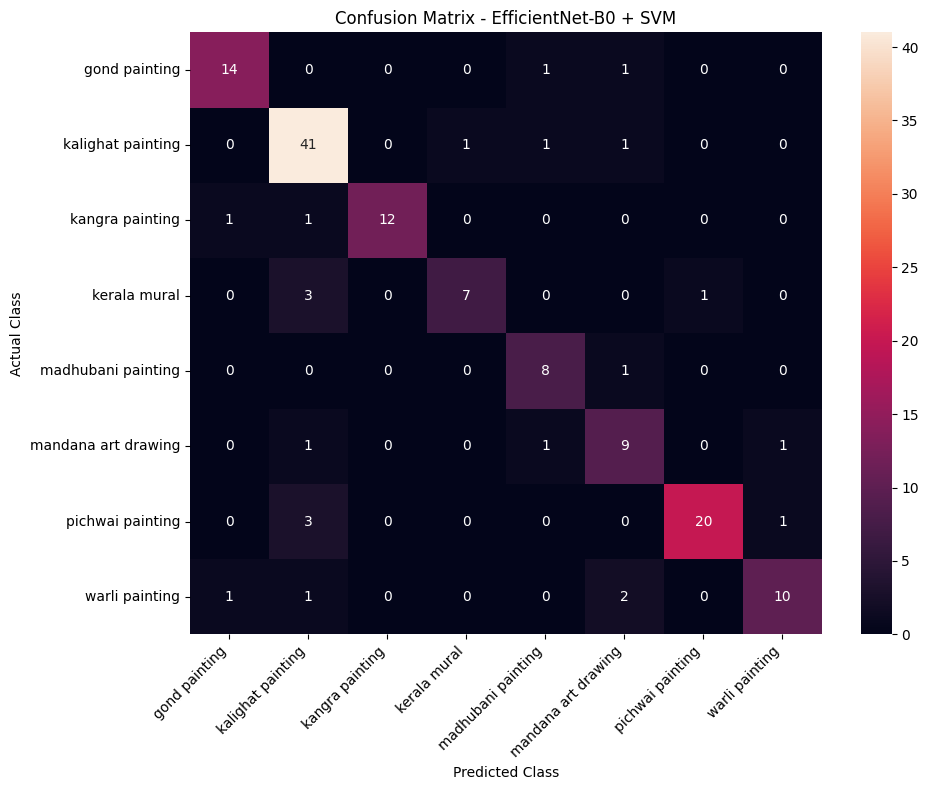

In [ ]:
# ============================================================
# CELL 29 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_labels,
    test_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=base_dataset.classes,
    yticklabels=base_dataset.classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Confusion Matrix - EfficientNet-B0 + SVM"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# CELL 30 — OVERALL SVM METRICS
# ============================================================

macro_precision = precision_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

print("========== EfficientNet-B0 + SVM Metrics ==========")

print(f"Test Accuracy   : {test_accuracy:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Weighted F1     : {weighted_f1:.4f}")

========== EfficientNet-B0 + SVM Metrics ==========
Test Accuracy   : 0.8403
Macro Precision : 0.8407
Macro Recall    : 0.8109
Macro F1        : 0.8197
Weighted F1     : 0.8404


In [ ]:
# ============================================================
# CELL 31 — SAVE SVM MODEL AND RESULTS TO GOOGLE DRIVE
# ============================================================

import os
import joblib

# Drive directory
save_dir = "/content/drive/MyDrive/Iconography/Implementation/EfficientNet-B0"

os.makedirs(save_dir, exist_ok=True)

# ------------------------------------------------------------
# Save trained SVM
# ------------------------------------------------------------

svm_model_path = os.path.join(
    save_dir,
    "efficientnet_b0_svm_rbf.pkl"
)

joblib.dump(
    svm_model,
    svm_model_path
)

# ------------------------------------------------------------
# Save overall metrics
# ------------------------------------------------------------

overall_metrics = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],
    "Score": [
        test_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_f1
    ]
})

metrics_path = os.path.join(
    save_dir,
    "efficientnet_b0_svm_metrics.csv"
)

overall_metrics.to_csv(
    metrics_path,
    index=False
)

# ------------------------------------------------------------
# Save class-wise metrics
# ------------------------------------------------------------

class_metrics_path = os.path.join(
    save_dir,
    "efficientnet_b0_svm_class_metrics.csv"
)

class_metrics.to_csv(
    class_metrics_path
)

print("SVM and evaluation results saved successfully!")
print("\nSaved files:")

print("EfficientNet model:")
print(
    os.path.join(
        save_dir,
        "best_efficientnet_b0_indian_paintings.pth"
    )
)

print("\nSVM model:")
print(svm_model_path)

print("\nOverall metrics:")
print(metrics_path)

print("\nClass-wise metrics:")
print(class_metrics_path)

SVM and evaluation results saved successfully!

Saved files:
EfficientNet model:
/content/drive/MyDrive/Iconography/Implementation/EfficientNet-B0/best_efficientnet_b0_indian_paintings.pth

SVM model:
/content/drive/MyDrive/Iconography/Implementation/EfficientNet-B0/efficientnet_b0_svm_rbf.pkl

Overall metrics:
/content/drive/MyDrive/Iconography/Implementation/EfficientNet-B0/efficientnet_b0_svm_metrics.csv

Class-wise metrics:
/content/drive/MyDrive/Iconography/Implementation/EfficientNet-B0/efficientnet_b0_svm_class_metrics.csv


In [ ]:
# ============================================================
# CELL 32 — SAVE EXTRACTED FEATURES TO GOOGLE DRIVE
# ============================================================

feature_dir = os.path.join(
    save_dir,
    "features"
)

os.makedirs(feature_dir, exist_ok=True)

# Save training features and labels
np.save(
    os.path.join(feature_dir, "train_features.npy"),
    train_features
)

np.save(
    os.path.join(feature_dir, "train_labels.npy"),
    train_labels
)

# Save validation features and labels
np.save(
    os.path.join(feature_dir, "val_features.npy"),
    val_features
)

np.save(
    os.path.join(feature_dir, "val_labels.npy"),
    val_labels
)

# Save test features and labels
np.save(
    os.path.join(feature_dir, "test_features.npy"),
    test_features
)

np.save(
    os.path.join(feature_dir, "test_labels.npy"),
    test_labels
)

print("Extracted features saved successfully!")

print("\nFeature directory:")
print(feature_dir)

Extracted features saved successfully!

Feature directory:
/content/drive/MyDrive/Iconography/Implementation/EfficientNet-B0/features


In [ ]:
# ============================================================
# CELL 33 — SAVE CONFUSION MATRIX
# ============================================================

cm_df = pd.DataFrame(
    cm,
    index=base_dataset.classes,
    columns=base_dataset.classes
)

cm_path = os.path.join(
    save_dir,
    "efficientnet_b0_svm_confusion_matrix.csv"
)

cm_df.to_csv(cm_path)

print("Confusion matrix saved successfully!")
print("Saved to:", cm_path)

Confusion matrix saved successfully!
Saved to: /content/drive/MyDrive/Iconography/Implementation/EfficientNet-B0/efficientnet_b0_svm_confusion_matrix.csv


In [ ]:
# ============================================================
# CELL 34 — FINAL METRICS SUMMARY
# ============================================================

final_results = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],
    "Score": [
        test_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_f1
    ]
})

print("================================================")
print("FINAL RESULTS — EFFICIENTNET-B0 + SVM")
print("================================================")

display(final_results)

FINAL RESULTS — EFFICIENTNET-B0 + SVM


,Metric,Score
0,Test Accuracy,0.840278
1,Macro Precision,0.840731
2,Macro Recall,0.810854
3,Macro F1,0.819711
4,Weighted F1,0.840428


In [ ]:
# ============================================================
# CELL 37 — FINAL EFFICIENTNET-B0 + SVM SUMMARY
# ============================================================

print("=" * 75)
print("EFFICIENTNET-B0 + SVM — FINAL EXPERIMENT SUMMARY")
print("=" * 75)

# ============================================================
# MODEL
# ============================================================

print("\nMODEL")
print("-" * 75)
print("Feature Extractor          : EfficientNet-B0")
print("Classifier                 : SVM")
print("SVM Kernel                 : RBF")
print("Pretrained weights         : ImageNet")
print("Number of classes          :", NUM_CLASSES)
print("Input resolution           : 224 x 224")
print("Feature dimension          :", num_features)

# ============================================================
# PERFORMANCE
# ============================================================

print("\nPERFORMANCE")
print("-" * 75)
print(f"Validation Accuracy        : {val_accuracy:.4f}")
print(f"Test Accuracy              : {test_accuracy:.4f}")
print(f"Test Precision             : {macro_precision:.4f}")
print(f"Test Recall                : {macro_recall:.4f}")
print(f"Test F1-Score              : {macro_f1:.4f}")
print(f"Weighted F1-Score          : {weighted_f1:.4f}")

# ============================================================
# TRAINING BENCHMARK
# ============================================================

print("\nTRAINING BENCHMARK")
print("-" * 75)

print(
    f"SVM Training Time          : "
    f"{svm_training_time:.2f} sec"
)

print(
    "EfficientNet Training      : "
    "Completed separately using the trained checkpoint"
)

# ============================================================
# INFERENCE BENCHMARK
# ============================================================

print("\nINFERENCE BENCHMARK")
print("-" * 75)

# Measure SVM prediction time on the complete test feature set
svm_inference_start = time.time()

_ = svm_model.predict(test_features)

svm_inference_total_time = (
    time.time() - svm_inference_start
)

average_svm_inference_time = (
    svm_inference_total_time / len(test_features)
)

svm_inference_throughput = (
    len(test_features) / svm_inference_total_time
)

print(
    f"SVM Inference Time         : "
    f"{svm_inference_total_time:.4f} sec"
)

print(
    f"Average SVM Inference Time : "
    f"{average_svm_inference_time * 1000:.4f} ms/image"
)

print(
    f"SVM Throughput             : "
    f"{svm_inference_throughput:.2f} images/sec"
)

# ============================================================
# MODEL COMPLEXITY
# ============================================================

print("\nMODEL COMPLEXITY")
print("-" * 75)

# EfficientNet-B0 backbone parameters
efficientnet_model = models.efficientnet_b0(
    weights=None
)

efficientnet_total_parameters = sum(
    p.numel()
    for p in efficientnet_model.parameters()
)

print(
    f"EfficientNet-B0 Parameters : "
    f"{efficientnet_total_parameters:,}"
)

print(
    f"EfficientNet Feature Size  : "
    f"{num_features}"
)

# SVM complexity information
print(
    f"SVM Support Vectors        : "
    f"{len(svm_model.support_):,}"
)

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

print("\nOUTPUT DIRECTORY")
print("-" * 75)
print(save_dir)

# ============================================================
# SAVED MODELS
# ============================================================

print("\nSAVED MODELS")
print("-" * 75)

print(
    "EfficientNet checkpoint    : "
    "best_efficientnet_b0_indian_paintings.pth"
)

print(
    "SVM model                  : "
    "efficientnet_b0_svm_rbf.pkl"
)

# ============================================================
# COMPLETION
# ============================================================

print("\n" + "=" * 75)
print("✓ EfficientNet-B0 + SVM experiment completed.")
print("=" * 75)

EFFICIENTNET-B0 + SVM — FINAL EXPERIMENT SUMMARY

MODEL
---------------------------------------------------------------------------
Feature Extractor          : EfficientNet-B0
Classifier                 : SVM
SVM Kernel                 : RBF
Pretrained weights         : ImageNet
Number of classes          : 8
Input resolution           : 224 x 224
Feature dimension          : 1280

PERFORMANCE
---------------------------------------------------------------------------
Validation Accuracy        : 0.7817
Test Accuracy              : 0.8403
Test Precision             : 0.8407
Test Recall                : 0.8109
Test F1-Score              : 0.8197
Weighted F1-Score          : 0.8404

TRAINING BENCHMARK
---------------------------------------------------------------------------
SVM Training Time          : 0.43 sec
EfficientNet Training      : Completed separately using the trained checkpoint

INFERENCE BENCHMARK
---------------------------------------------------------------------------
